# Unit13_Example_07 | 化工案例五：結合 ODE 求解之反應動力學參數估計 — 醱酵程序

本 Notebook 以 **盤尼西林醱酵程序** 動力學為題，示範如何在模式函數內嵌 `scipy.integrate.solve_ivp()` 求解 ODE，再以 `scipy.optimize.curve_fit()` 估計四個速率常數 $k_1, k_2, k_3, k_4$ 並計算 95% 置信區間。

## 目標
- 理解 Logistic 細胞生長模型與盤尼西林生成/降解 ODE 的物理意義
- 掌握「雙狀態觀測合併」策略：`ydata = np.concatenate([y1_data, y2_data])`
- 在模式函數內呼叫 `solve_ivp()` 獲取各時間點 ODE 預測值
- 使用 `curve_fit(method='trf', bounds=...)` 估計有界非線性最小平方問題
- 由協方差矩陣 `pcov` 推算 95% 置信區間
- 分別繪製 $y_1$ (細胞濃度) 與 $y_2$ (盤尼西林濃度) 的擬合結果圖

## 大綱
0. 環境設定
1. 載入套件
2. 問題描述與實驗數據
3. ODE 系統與模式函數定義
4. 參數估計與 95% 置信區間
5. 各量測點驗證
6. 結果視覺化

---
### 0. 環境設定

In [10]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit13_Example_07'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit13'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit13
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit13\outputs\Unit13_Example_07
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit13\outputs\Unit13_Example_07\figs


---
### 1. 載入套件

In [11]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scipy
import warnings
warnings.filterwarnings('ignore')
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit
from scipy.stats import t as t_dist

# 繪圖樣式設定
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'lines.linewidth': 2,
    'axes.unicode_minus': False,
})

print(f"NumPy   : {np.__version__}")
print(f"SciPy   : {scipy.__version__}")
print(f"Matplotlib: {matplotlib.__version__}")
print("✓ 套件載入完成")


NumPy   : 1.23.5
SciPy   : 1.15.2
Matplotlib: 3.10.8
✓ 套件載入完成


---
### 2. 問題描述與實驗數據

**盤尼西林醱酵程序** 動力學模式（Constantinides and Mostoufi, 1999）：

$$\frac{dy_1}{dt} = k_1 y_1 \left(1 - \frac{y_1}{k_2}\right), \quad \frac{dy_2}{dt} = k_3 y_1 - k_4 y_2$$

- $y_1$ ：細胞濃度（% dry weight），Logistic 生長模型
- $y_2$ ：盤尼西林濃度（units/mL），生成速率 $k_3 y_1$ ，降解速率 $k_4 y_2$
- 初始條件： $y_1(0) = 0.18,\ y_2(0) = 0$
- 待估計： $k_1, k_2, k_3, k_4$ （共 4 個速率常數）


In [12]:
# ============================================================
# 實驗數據 (Constantinides and Mostoufi, 1999)
# ============================================================
t_data = np.array([0, 10, 22, 34, 46, 58, 70, 82, 94,
                   106, 118, 130, 142, 154, 166, 178, 190, 210], dtype=float)

y1_data = np.array([0.18, 0.12, 0.48, 1.46, 1.56, 1.73, 1.99, 2.62, 2.88,
                    3.43, 3.37, 3.92, 3.96, 3.58, 3.58, 3.34, 3.47, 3.45])

y2_data = np.array([0.0000, 0.0000, 0.0089, 0.0062, 0.2266, 0.4373, 0.6943, 1.2459, 1.4315,
                    2.0402, 1.9278, 2.1848, 2.4204, 2.4615, 2.2830, 2.7078, 2.6542, 2.6831])

n = len(t_data)

# print summary
print(f"{'時間 t (hr)':>12s}  {'y1 細胞濃度 (% dry wt)':>22s}  {'y2 盤尼西林 (units/mL)':>22s}")
print("-" * 63)
for i in range(n):
    print(f"{t_data[i]:>12.0f}  {y1_data[i]:>22.4f}  {y2_data[i]:>22.4f}")
print(f"\n時間點數 n = {n}，量測值總數 = {2*n}")

   時間 t (hr)      y1 細胞濃度 (% dry wt)      y2 盤尼西林 (units/mL)
---------------------------------------------------------------
           0                  0.1800                  0.0000
          10                  0.1200                  0.0000
          22                  0.4800                  0.0089
          34                  1.4600                  0.0062
          46                  1.5600                  0.2266
          58                  1.7300                  0.4373
          70                  1.9900                  0.6943
          82                  2.6200                  1.2459
          94                  2.8800                  1.4315
         106                  3.4300                  2.0402
         118                  3.3700                  1.9278
         130                  3.9200                  2.1848
         142                  3.9600                  2.4204
         154                  3.5800                  2.4615
         166         

---
### 3. ODE 系統與模式函數定義

**關鍵設計：** 將雙狀態量測合併 `ydata = np.concatenate([y1_data, y2_data])`，模式函數接收時間陣列，在內部呼叫 `solve_ivp()` 並返回長度 $2n$ 的預測向量。

In [13]:
# ============================================================
# 初始條件
# ============================================================
y0 = [0.18, 0.0]   # [y1(0), y2(0)]


# ============================================================
# ODE 系統定義
# ============================================================
def fermentation_odes(t, y, k1, k2, k3, k4):
    """
    盤尼西林醱酵程序動力學 ODE 系統
    dy1/dt = k1 * y1 * (1 - y1/k2)   (Logistic 細胞生長)
    dy2/dt = k3 * y1 - k4 * y2        (盤尼西林生成與降解)
    """
    y1, y2 = y
    dy1dt = k1 * y1 * (1.0 - y1 / k2)
    dy2dt = k3 * y1 - k4 * y2
    return [dy1dt, dy2dt]


# ============================================================
# 模式函數（供 curve_fit 呼叫）
# ============================================================
def model_func(t_arr, k1, k2, k3, k4):
    """
    供 curve_fit 呼叫之模式函數
    輸入: t_arr (n,)  — 實驗時間點
    輸出: np.concatenate([y1_pred, y2_pred]) (2n,)
    """
    try:
        sol = solve_ivp(
            fermentation_odes,
            t_span=[t_arr[0], t_arr[-1]],
            y0=y0,
            args=(k1, k2, k3, k4),
            t_eval=t_arr,
            method='RK45',
            rtol=1e-6,
            atol=1e-8,
            dense_output=False,
        )
        if not sol.success:
            return np.full(2 * len(t_arr), 1e6)
        return np.concatenate([sol.y[0], sol.y[1]])
    except Exception:
        return np.full(2 * len(t_arr), 1e6)


# ============================================================
# 自檢：以初始猜測值計算預測值
# ============================================================
p0_check = [0.05, 3.5, 0.02, 0.02]
y_check  = model_func(t_data, *p0_check)
print("模式函數自檢（初始猜測值 p0 = [0.05, 3.5, 0.02, 0.02]）：")
print(f"  t=0 → y1={y_check[0]:.4f}, y2={y_check[n]:.4f}")
print(f"  t=94 → y1={y_check[8]:.4f}, y2={y_check[n+8]:.4f}")
print(f"  t=210 → y1={y_check[17]:.4f}, y2={y_check[n+17]:.4f}")
print(f"  輸出向量長度: {len(y_check)} (= 2 × {n})")

模式函數自檢（初始猜測值 p0 = [0.05, 3.5, 0.02, 0.02]）：
  t=0 → y1=0.1800, y2=0.0000
  t=94 → y1=2.9972, y2=1.5967
  t=210 → y1=3.4982, y2=3.2779
  輸出向量長度: 36 (= 2 × 18)


---
### 4. 參數估計與 95% 置信區間

使用 `scipy.optimize.curve_fit(method='trf')` 進行有界非線性最小平方求解，同時擬合 $y_1$ 與 $y_2$。

In [14]:
# ============================================================
# 合併量測值向量（雙狀態）
# ============================================================
ydata = np.concatenate([y1_data, y2_data])   # 長度 = 2n = 36

# ============================================================
# 初始猜測值與邊界設定
# ============================================================
p0 = [0.05, 3.5, 0.02, 0.02]                  # [k1, k2, k3, k4]
bounds_lower = [1e-4, 1.0,  1e-5, 1e-5]
bounds_upper = [1.0,  10.0, 1.0,  1.0 ]

# ============================================================
# curve_fit 求解
# ============================================================
popt, pcov = curve_fit(
    model_func,
    t_data,
    ydata,
    p0=p0,
    bounds=(bounds_lower, bounds_upper),
    method='trf',
    maxfev=20000,
    ftol=1e-10,
    xtol=1e-10,
)

k1_est, k2_est, k3_est, k4_est = popt

# ============================================================
# 95% 置信區間
# ============================================================
n_obs    = len(ydata)       # = 36
n_params = len(popt)        # = 4
dof      = n_obs - n_params # = 32
t_crit   = t_dist.ppf(0.975, dof)

std_params = np.sqrt(np.diag(pcov))
ci_lower   = popt - t_crit * std_params
ci_upper   = popt + t_crit * std_params

# ============================================================
# 計算 SSE 與 MAE
# ============================================================
y_pred = model_func(t_data, *popt)
y1_pred = y_pred[:n]
y2_pred = y_pred[n:]

sse_y1 = np.sum((y1_data - y1_pred) ** 2)
sse_y2 = np.sum((y2_data - y2_pred) ** 2)
sse_total = sse_y1 + sse_y2
mae_y1 = np.mean(np.abs(y1_data - y1_pred))
mae_y2 = np.mean(np.abs(y2_data - y2_pred))

# ============================================================
# 結果輸出
# ============================================================
param_names = ['k1 (1/hr)', 'k2 (% dw)', 'k3        ', 'k4 (1/hr)']
print("=" * 70)
print(f"{'參數':<12s}  {'估計值':>10s}  {'標準誤':>10s}  {'95% CI 下界':>12s}  {'95% CI 上界':>12s}")
print("-" * 70)
for i, name in enumerate(param_names):
    print(f"{name:<12s}  {popt[i]:>10.4f}  {std_params[i]:>10.5f}  {ci_lower[i]:>12.4f}  {ci_upper[i]:>12.4f}")
print("=" * 70)
print(f"SSE (combined) = {sse_total:.4f}  (y1: {sse_y1:.4f}, y2: {sse_y2:.4f})")
print(f"MAE y1 = {mae_y1:.4f}  MAE y2 = {mae_y2:.4f}")
print(f"自由度 ν = {dof}，t(0.975,{dof}) = {t_crit:.4f}")

參數                   估計值         標準誤     95% CI 下界     95% CI 上界
----------------------------------------------------------------------
k1 (1/hr)         0.0502     0.00204        0.0460        0.0543
k2 (% dw)         3.6088     0.07988        3.4461        3.7715
k3                0.0203     0.00385        0.0125        0.0281
k4 (1/hr)         0.0262     0.00646        0.0130        0.0393
SSE (combined) = 1.4865  (y1: 1.1705, y2: 0.3160)
MAE y1 = 0.1892  MAE y2 = 0.1001
自由度 ν = 32，t(0.975,32) = 2.0369


---
### 5. 各量測點驗證

逐點比較實驗值與模式預測值。

In [15]:
# ============================================================
# 細胞濃度 y1 各點比較
# ============================================================
print("細胞濃度 y1 各量測點比較：")
print(f"{'t (hr)':>8s}  {'y1_量測':>10s}  {'y1_模型':>10s}  {'誤差':>10s}  {'相對誤差(%)':>12s}")
print("-" * 60)
for i in range(n):
    err = y1_data[i] - y1_pred[i]
    rel = abs(err) / y1_data[i] * 100 if y1_data[i] > 0.01 else float('nan')
    rel_str = f"{rel:>12.2f}" if not np.isnan(rel) else f"{'—':>12s}"
    print(f"{t_data[i]:>8.0f}  {y1_data[i]:>10.4f}  {y1_pred[i]:>10.4f}  {err:>10.4f}  {rel_str}")
print(f"SSE(y1) = {sse_y1:.4f}   MAE(y1) = {mae_y1:.4f}\n")

# ============================================================
# 盤尼西林濃度 y2 各點比較
# ============================================================
print("盤尼西林濃度 y2 各量測點比較：")
print(f"{'t (hr)':>8s}  {'y2_量測':>10s}  {'y2_模型':>10s}  {'誤差':>10s}  {'相對誤差(%)':>12s}")
print("-" * 60)
for i in range(n):
    err = y2_data[i] - y2_pred[i]
    rel = abs(err) / y2_data[i] * 100 if y2_data[i] > 0.01 else float('nan')
    rel_str = f"{rel:>12.2f}" if not np.isnan(rel) else f"{'—':>12s}"
    print(f"{t_data[i]:>8.0f}  {y2_data[i]:>10.4f}  {y2_pred[i]:>10.4f}  {err:>10.4f}  {rel_str}")
print(f"SSE(y2) = {sse_y2:.4f}   MAE(y2) = {mae_y2:.4f}")

細胞濃度 y1 各量測點比較：
  t (hr)       y1_量測       y1_模型          誤差       相對誤差(%)
------------------------------------------------------------
       0      0.1800      0.1800      0.0000          0.00
      10      0.1200      0.2880     -0.1680        139.96
      22      0.4800      0.4933     -0.0133          2.77
      34      1.4600      0.8094      0.6506         44.56
      46      1.5600      1.2471      0.3129         20.06
      58      1.7300      1.7716     -0.0416          2.40
      70      1.9900      2.3017     -0.3117         15.66
      82      2.6200      2.7527     -0.1327          5.07
      94      2.8800      3.0836     -0.2036          7.07
     106      3.4300      3.3010      0.1290          3.76
     118      3.3700      3.4335     -0.0635          1.88
     130      3.9200      3.5106      0.4094         10.44
     142      3.9600      3.5544      0.4056         10.24
     154      3.5800      3.5788      0.0012          0.03
     166      3.5800      3.5923     -

---
### 6. 結果視覺化

分別繪製細胞濃度 $y_1$ 與盤尼西林濃度 $y_2$ 之實驗值與模式預測曲線。

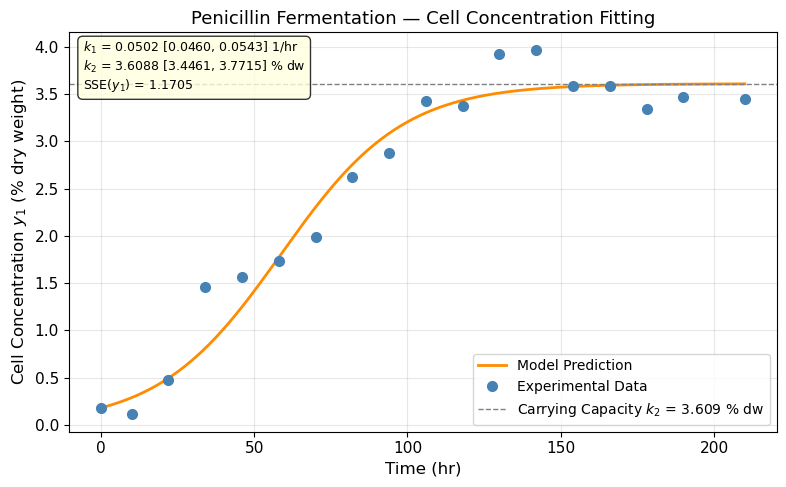

✓ 圖檔已儲存: d:\MyGit\ChemE-3502\Unit13\outputs\Unit13_Example_07\figs\fermentation_y1_fitting.png


In [16]:
# ============================================================
# 平滑曲線時間軸（用於繪製連續曲線）
# ============================================================
t_smooth = np.linspace(t_data[0], t_data[-1], 500)
y_smooth = model_func(t_smooth, *popt)
y1_smooth = y_smooth[:500]
y2_smooth = y_smooth[500:]

# ============================================================
# 圖一：細胞濃度 y1 擬合結果
# ============================================================
fig1, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(t_smooth, y1_smooth, '-', color='darkorange', lw=2, label='Model Prediction')
ax1.plot(t_data, y1_data, 'o', color='steelblue', ms=7, zorder=5,
         label='Experimental Data')

ax1.axhline(k2_est, color='gray', ls='--', lw=1.0, label=f'Carrying Capacity $k_2$ = {k2_est:.3f} % dw')

ax1.set_xlabel('Time (hr)', fontsize=12)
ax1.set_ylabel('Cell Concentration $y_1$ (% dry weight)', fontsize=12)
ax1.set_title('Penicillin Fermentation — Cell Concentration Fitting', fontsize=13)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# 參數標注
param_text = (
    f"$k_1$ = {k1_est:.4f} [{ci_lower[0]:.4f}, {ci_upper[0]:.4f}] 1/hr\n"
    f"$k_2$ = {k2_est:.4f} [{ci_lower[1]:.4f}, {ci_upper[1]:.4f}] % dw\n"
    f"SSE($y_1$) = {sse_y1:.4f}"
)
ax1.text(0.02, 0.98, param_text, transform=ax1.transAxes, fontsize=9,
         verticalalignment='top', bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
fig1_path = FIG_DIR / 'fermentation_y1_fitting.png'
fig1.savefig(fig1_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ 圖檔已儲存: {fig1_path}")

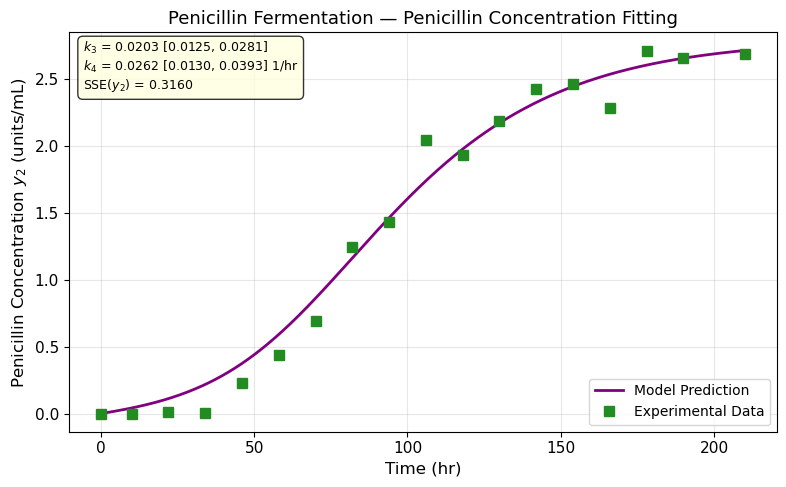

✓ 圖檔已儲存: d:\MyGit\ChemE-3502\Unit13\outputs\Unit13_Example_07\figs\fermentation_y2_fitting.png


In [17]:
# ============================================================
# 圖二：盤尼西林濃度 y2 擬合結果
# ============================================================
fig2, ax2 = plt.subplots(figsize=(8, 5))

ax2.plot(t_smooth, y2_smooth, '-', color='purple', lw=2, label='Model Prediction')
ax2.plot(t_data, y2_data, 's', color='forestgreen', ms=7, zorder=5,
         label='Experimental Data')

ax2.set_xlabel('Time (hr)', fontsize=12)
ax2.set_ylabel('Penicillin Concentration $y_2$ (units/mL)', fontsize=12)
ax2.set_title('Penicillin Fermentation — Penicillin Concentration Fitting', fontsize=13)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# 參數標注
param_text2 = (
    f"$k_3$ = {k3_est:.4f} [{ci_lower[2]:.4f}, {ci_upper[2]:.4f}]\n"
    f"$k_4$ = {k4_est:.4f} [{ci_lower[3]:.4f}, {ci_upper[3]:.4f}] 1/hr\n"
    f"SSE($y_2$) = {sse_y2:.4f}"
)
ax2.text(0.02, 0.98, param_text2, transform=ax2.transAxes, fontsize=9,
         verticalalignment='top', bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
fig2_path = FIG_DIR / 'fermentation_y2_fitting.png'
fig2.savefig(fig2_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ 圖檔已儲存: {fig2_path}")